<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/11_the-beauty-of-knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 11: The beauty of kNN

In this exercise, you'll gain practice working with kNN. We'll use the [diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) dataset, which comes as part of `ggplot2`. This dataset provides information on the quality and price of 50,000 diamonds


## 1. Data, Plotting, and Train/Test Sets (2 pts)
-----
* Load the the `class` and `tidyverse` packages.
* Assign the `diamonds` data set to a simpler name. Then, create a new variable `price_bin` that splits the `price` variable into a binary variable, where 1 indicates that the diamond costs greater than the mean price, and 0 indicates that the diamond costs less than the mean price. Set `price_bin` to be a factor. (*Hint: use the if_else() function*)
* Select just the `carat`, `depth`, `table`, `x`, `y`, and your new `price_bin` variables
* Print the first few lines of the data set
* Print the dimensions of the data set


In [2]:
# INSERT CODE HERE
library(class)
library(tidyverse)

df <- diamonds %>%
  mutate(price_bin=if_else(price > mean(price),1,0), 
    price_bin = as.factor(price_bin)) %>%
  select(carat, depth, table, x, y, price_bin)

head(df)

dim(df)


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0.23,61.5,55,3.95,3.98,0
0.21,59.8,61,3.89,3.84,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0


[1] 53940     6

### Plot
Create a scatterplot of the link between `carat` and `depth`, and use the `color` aesthetics mapping to differentiate between diamonds that cost above versus below the mean price.

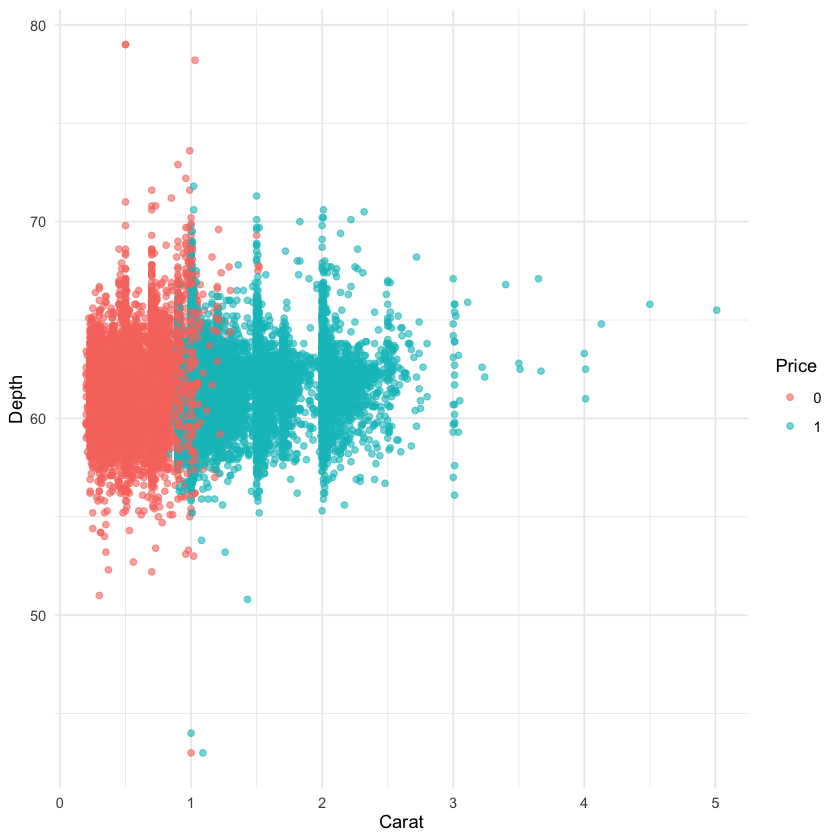

In [4]:
# INSERT CODE HERE
library(ggplot2)

ggplot(df, aes(x=carat, y=depth, color=price_bin)) +
  geom_point(alpha=0.6) +
  labs(x="Carat", y="Depth", color="Price") +
  theme_minimal()


Based on the above scatterplot, how do you think kNN will perform using only these two variables to predict diabetes diagnosis? Which variable, carat or depth, gives us the most information about which price class the diamond will belong to?
> * *Write response here*
> It might perform okay, but likely not great. There is a good amount of overlap in the points when using just carat and depth to determine price bin. Carat gives us the most information about which price class the diamond will belong to. 
> *


### Test vs Train

Before we run KNN on these data, we need to set aside a portion of the observations as our test set. Below, randomly divide the data such that 30% are allotted to the `test` set and the rest are allotted to the `train` set. Print the first few lines of each set, and print the dimensions of each set to double check your division of the data.

In [5]:
smp_size <- floor(0.7 * nrow(df))

set.seed(2023)

train_ind <- sample(seq_len(nrow(df)), size = smp_size)

train_set <- df[train_ind, ]
test_set  <- df[-train_ind, ]

head(train_set)
head(test_set)

dim(train_set)
dim(test_set)


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1.22,62.3,56.0,6.81,6.84,1
1.57,62.3,56.0,7.48,7.41,1
1.11,62.4,57.7,6.57,6.64,1
0.42,60.6,57.0,4.82,4.85,0
0.32,62.6,55.0,4.39,4.36,0
0.90,62.7,58.0,6.06,6.15,1


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0.23,61.5,55,3.95,3.98,0
0.26,61.9,55,4.07,4.11,0
0.22,65.1,61,3.87,3.78,0
0.23,62.8,56,3.93,3.90,0
0.31,62.2,54,4.35,4.37,0
0.20,60.2,62,3.79,3.75,0


[1] 37758     6

[1] 16182     6

## 2: KNN (3 points)
----
Now, use the `knn()` function from the `class` library to predict `price_bin` from the `carat` and `depth`. Set `k = 3`.

*Hint: Review the format required for the arguments of knn()*

In [8]:
set.seed(2023)

train_x <- train_set[, c("carat", "depth")]
test_x  <- test_set[, c("carat", "depth")]

train_y <- train_set$price_bin

knn_output <- knn(
  train=train_x,
  test=test_x,
  cl=train_y,
  k=3)


Now, output a confusion matrix and calculate the test error to evaluate model performance.

In [9]:
# INSERT CODE HERE

test_y <- factor(test_set$price_bin)

confusion_matrix <- table(Predicted=knn_output, Actual=test_y)
print(confusion_matrix)

test_error <- 1 - sum(diag(confusion_matrix)) / sum(confusion_matrix)
print(paste("Test error:", round(test_error, 3)))


         Actual
Predicted    0    1
        0 9756  302
        1  542 5582
[1] "Test error: 0.052"


How did your model perform?
> * Write your response here
> Performed overall well. Only 5% of cases were misclassified. There is a slightly higher chance that the mdoel classifies 0s as 1s versus classifying 1s as 0s. 
> *


Let's try to improve our model by adding all of the other variables in our data set as predictors. Rerun your `knn()` below, keeping `k = 3`. Again, output a confusion matrix and error rate for your updated model fit.

In [10]:
set.seed(2023)

train_x_all <- train_set[, c("carat", "depth", "table", "x", "y")]
test_x_all  <- test_set[, c("carat", "depth", "table", "x", "y")]

train_y <- factor(train_set$price_bin)
test_y  <- factor(test_set$price_bin)

knn_output_all <- knn(
  train=train_x_all,
  test=test_x_all,
  cl=train_y,
  k=3)

confusion_matrix_all <- table(Predicted=knn_output_all, Actual=test_y)
print(confusion_matrix_all)

test_error_all <- 1 - sum(diag(confusion_matrix_all)) / sum(confusion_matrix_all)
print(paste("Test error all predictors:", round(test_error_all, 3)))


         Actual
Predicted    0    1
        0 9782  367
        1  516 5517
[1] "Test error all predictors: 0.055"


Did your model predictions improve?
> * Write your response here
> Not really, model predictions only improved by .003 which is negligible.
> *


# 3: for loop (3 points)
----

So adding additional predictors didn't shift our error much. Let's see if adjusting `k` has a larger impact on model accuracy.

Using your initial model above with just `carat` and `depth`, run a `for loop` that runs the same model 30 times, for `k = 1:30`.

Output a data frame that has `k` and the overall `error` as columns.

The structure of the output data frame and `for loop` are provided for you below. Note that your loop will take a minute or two to run because there are so many observations in the dataset. It may be helpful while you are writing and testing your loop to run it on a subset of the data with only a handful of rows.

In [11]:
# this is provided
# setting up empty table to store for loop output
output  <- data.frame(k = seq(1:30),
                     error = rep(NA, 30))
head(output)

,k,error
,<int>,<lgl>
1,1,NA
2,2,NA
3,3,NA
4,4,NA
5,5,NA
6,6,NA


In [14]:
for (k in seq(1:30)) {
    knn_fits  <- knn(train=train_x,
                     test=test_x,
                     cl=train_y,
                     k=k)

    #overall error
    conf_df  <- data.frame(Predicted=knn_fits, Actual=test_y)
    output$error[k] <- 1 - mean(conf_df$Predicted == conf_df$Actual)
}
head(output)

,k,error
,<int>,<dbl>
1,1,0.05413422
2,2,0.05462860
3,3,0.05215672
4,4,0.05122976
5,5,0.05147695
6,6,0.05147695


Create a line plot of your `output` object using `ggplot`. Add a (non-linear) `geom_smooth` layer.

`geom_smooth()` using formula = 'y ~ x'


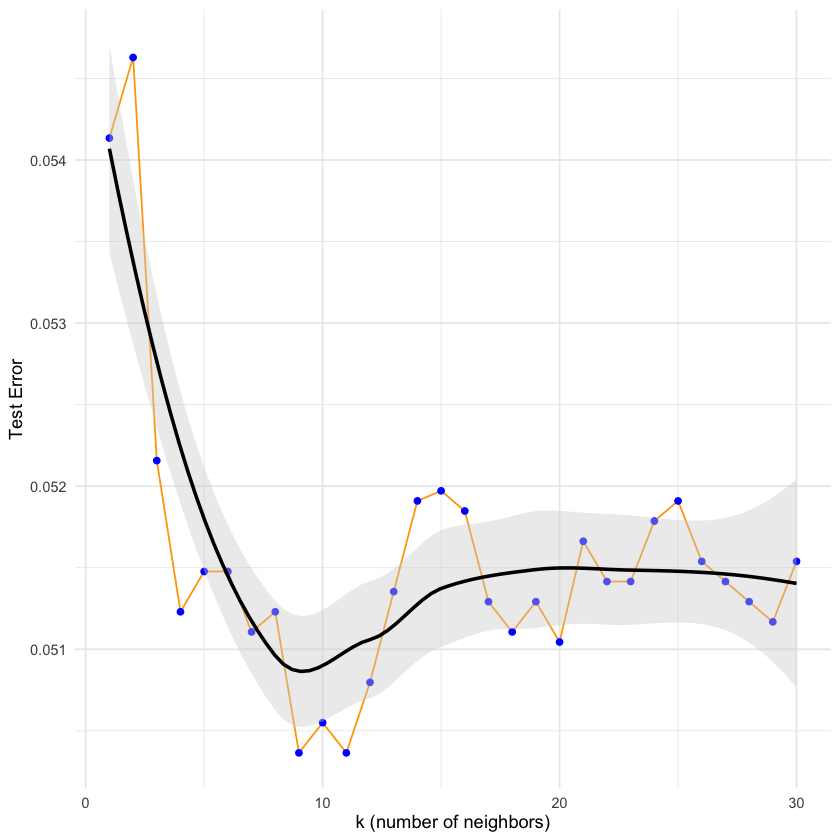

In [15]:
# INSERT CODE HERE

ggplot(output, aes(x=k, y=error)) +
  geom_line(color="orange") +       
  geom_point(color="blue") +        
  geom_smooth(method="loess", se = TRUE, color = "black", fill = "lightgray") +
  labs(x = "k (number of neighbors)", y="Test Error") +
  theme_minimal()

Interpret your plot. What would you select as the best value of `k`? How much does this improve your test error?
> * *Write your response here*
> About 9 is the lowest point on the plot and therefore the best valie of k. The error at the lowest point (k=9) is estimated visually to be around .015. At baseline, error is closer to .055 which means there was clsoe to 73% improvement in test error. 
> *


# 4: Standardizing predictors (2)
-----

Because knn is based on distances between points, it is very sensitive to the scale of your variables. Looking at our predictor variables, we can see that `carat` and `depth` are orders of magnitude different in terms of scales. Maybe we can improve our fit even more by addressing this!

Below, use the `scale()` function to standardize your predictors. (Note that you don't need to standardize `price_bin`.)

Then, run your model a final time with your standardized predictors (just `carat` and `depth` still). Set `k` to the optimal value you determined in your plot above. Output the confusion matrix and error rate again.

In [17]:
set.seed(2023)
#INSERT CODE HERE

train_x_scaled <- scale(train_set[, c("carat", "depth")])
test_x_scaled  <- scale(test_set[, c("carat", "depth")],
                        center=attr(train_x_scaled, "scaled:center"),
                        scale =attr(train_x_scaled, "scaled:scale"))

train_y <- factor(train_set$price_bin)
test_y  <- factor(test_set$price_bin)

k_optimal <- 9
knn_scaled <- knn(train=train_x_scaled,
                  test=test_x_scaled,
                  cl=train_y,
                  k=k_optimal)

confusion_matrix_scaled <- table(Predicted = knn_scaled, Actual = test_y)
print(confusion_matrix_scaled)

test_error_scaled <- 1 - sum(diag(confusion_matrix_scaled)) / sum(confusion_matrix_scaled)
print(paste("Test error:", round(test_error_scaled, 3)))


         Actual
Predicted    0    1
        0 9770  282
        1  528 5602
[1] "Test error: 0.05"


What impact did rescaling the data have on your error rate?
> * *Write response here*
> Rescaling the predictors very slightly improved the model by reducing the test error from 0.052 to 0.05
> *


**DUE:** 5pm March 17, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*
>
>
